# TTC Timings & Delay Analysis (2023)

This project analyzes Toronto Transit Commission (TTC) transit delay data for 2023, including
subway, streetcar, and bus services. The objective is to identify patterns in transit reliability
based on time of day, route, and delay cause using SQL-based analysis and data visualization.


## Research Questions

1. Which TTC routes and lines experienced the highest total delay time in 2023?
2. At what times of day do TTC delays occur most frequently?
3. What are the most common causes of TTC delays across transit modes?
4. Are delays more severe on weekdays compared to weekends?
5. How do delay patterns differ between subway, streetcar, and bus services?



The dataset used in this project contains publicly available TTC delay records for 2023,
sourced from Kaggle. Each dataset includes information such as:

- Date and time of delay
- Transit mode (subway, streetcar, bus)
- Route or line identifier
- Delay duration (in minutes)
- Reported delay cause or category.


In [18]:
import os

os.listdir("/kaggle/input")



['ttc-timings']

In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")



In [20]:
import pandas as pd

subway_df = pd.read_excel(
    "/kaggle/input/ttc-timings/ttc-subway-delay-data-2023.xlsx"
)

streetcar_df = pd.read_excel(
    "/kaggle/input/ttc-timings/ttc-streetcar-delay-data-2023.xlsx"
)

bus_df = pd.read_excel(
    "/kaggle/input/ttc-timings/ttc-bus-delay-data-2023.xlsx"
)


In [21]:
subway_df.head()
subway_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20882 entries, 0 to 20881
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       20882 non-null  datetime64[ns]
 1   Time       20882 non-null  object        
 2   Day        20882 non-null  object        
 3   Station    20882 non-null  object        
 4   Code       20882 non-null  object        
 5   Min Delay  20882 non-null  int64         
 6   Min Gap    20882 non-null  int64         
 7   Bound      13157 non-null  object        
 8   Line       20834 non-null  object        
 9   Vehicle    20882 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 1.6+ MB


In [22]:
import pandas as pd

# 1) Standardize column names
subway = subway_df.copy() # MAKE A COPY
subway.columns = (subway.columns
                  .str.strip()# REMOVE EXTRA HIDDEN SPACE, MAKE LOWERCASE, AND RENAME
                  .str.lower()
                  .str.replace(" ", "_"))

# 2) Rename key fields to consistent names for SQL
subway = subway.rename(columns={
    "min_delay": "delay_min",
    "min_gap": "gap_min"
})

# 3) Build a proper datetime column
# Date is already datetime64; Time is object (string like "13:45" usually)
subway["date"] = pd.to_datetime(subway["date"]).dt.date.astype("string")# select date, convert into pandas format, extract only the date part, and comvert to string
subway["date_time"] = pd.to_datetime(subway["date"] + " " + subway["time"], errors="coerce")#combine date and time into 1 string, if error it is NaT

# 4) Add analysis-friendly features
subway["hour"] = subway["date_time"].dt.hour# 2023-05-14 13:45 → 13
subway["day_of_week"] = subway["date_time"].dt.day_name()
subway["is_weekend"] = subway["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# 5) Fix missing values (keep it simple + honest)
subway["bound"] = subway["bound"].fillna("Unknown")
subway["line"] = subway["line"].fillna("Unknown")

subway.head()


,date,time,day,station,code,delay_min,gap_min,bound,line,vehicle,date_time,hour,day_of_week,is_weekend
0,2023-01-01,02:22,Sunday,MUSEUM STATION,MUPAA,3,9,S,YU,5931,2023-01-01 02:22:00,2,Sunday,1
1,2023-01-01,02:30,Sunday,KIPLING STATION,MUIS,0,0,E,BD,5341,2023-01-01 02:30:00,2,Sunday,1
2,2023-01-01,02:33,Sunday,WARDEN STATION,SUO,0,0,W,BD,0,2023-01-01 02:33:00,2,Sunday,1
3,2023-01-01,03:17,Sunday,KEELE STATION,MUIS,0,0,Unknown,BD,0,2023-01-01 03:17:00,3,Sunday,1
4,2023-01-01,07:16,Sunday,BATHURST STATION,MUIS,0,0,Unknown,BD,0,2023-01-01 07:16:00,7,Sunday,1


In [23]:
subway[["date_time","hour","day_of_week","is_weekend","delay_min","gap_min","line","bound"]].isna().sum()



date_time      0
hour           0
day_of_week    0
is_weekend     0
delay_min      0
gap_min        0
line           0
bound          0
dtype: int64

In [24]:
# doing the same cleaning for streetcar and bus as i did for subway

streetcar = streetcar_df.copy()
streetcar.columns = streetcar.columns.str.strip().str.lower().str.replace(" ", "_")
streetcar = streetcar.rename(columns={"min_delay": "delay_min", "min_gap": "gap_min"})

streetcar["date"] = pd.to_datetime(streetcar["date"]).dt.date.astype("string")
streetcar["date_time"] = pd.to_datetime(streetcar["date"] + " " + streetcar["time"].astype(str), errors="coerce")
streetcar["hour"] = streetcar["date_time"].dt.hour
streetcar["day_of_week"] = streetcar["date_time"].dt.day_name()
streetcar["is_weekend"] = streetcar["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# streetcar uses "incident" instead of "code"
streetcar = streetcar.rename(columns={"incident": "code"})
streetcar["bound"] = streetcar["bound"].fillna("Unknown") if "bound" in streetcar.columns else "Unknown"

streetcar.head()

,date,line,time,day,location,code,delay_min,gap_min,bound,vehicle,date_time,hour,day_of_week,is_weekend
0,2023-01-01,509,02:37,Sunday,QUEENS QUAY AND SPADIN,Operations,0,0,E,4403,2023-01-01 02:37:00,2,Sunday,1
1,2023-01-01,505,02:40,Sunday,BROADVIEW AND GERRARD,Held By,15,25,W,4460,2023-01-01 02:40:00,2,Sunday,1
2,2023-01-01,504,02:52,Sunday,KING AND BATHURST,Cleaning - Unsanitary,10,20,W,4427,2023-01-01 02:52:00,2,Sunday,1
3,2023-01-01,504,02:59,Sunday,KING AND BATHURST,Held By,25,35,E,4560,2023-01-01 02:59:00,2,Sunday,1
4,2023-01-01,509,03:33,Sunday,QUEENS QUAY AND SPADIN,Operations,0,0,E,4570,2023-01-01 03:33:00,3,Sunday,1


In [25]:
bus = bus_df.copy()
bus.columns = bus.columns.str.strip().str.lower().str.replace(" ", "_")
bus = bus.rename(columns={"min_delay": "delay_min", "min_gap": "gap_min"})

bus["date"] = pd.to_datetime(bus["date"]).dt.date.astype("string")
bus["date_time"] = pd.to_datetime(bus["date"] + " " + bus["time"].astype(str), errors="coerce")
bus["hour"] = bus["date_time"].dt.hour
bus["day_of_week"] = bus["date_time"].dt.day_name()
bus["is_weekend"] = bus["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

bus = bus.rename(columns={"incident": "code"}) if "incident" in bus.columns else bus
bus["direction"] = bus["direction"].fillna("Unknown") if "direction" in bus.columns else "Unknown"

bus.head()

,date,route,time,day,location,code,delay_min,gap_min,direction,vehicle,date_time,hour,day_of_week,is_weekend
0,2023-01-01,91,02:30,Sunday,WOODBINE AND MORTIMER,Diversion,81,111,Unknown,8772,2023-01-01 02:30:00,2,Sunday,1
1,2023-01-01,69,02:34,Sunday,WARDEN STATION,Security,22,44,S,8407,2023-01-01 02:34:00,2,Sunday,1
2,2023-01-01,35,03:06,Sunday,JANE STATION,Cleaning - Unsanitary,30,60,N,1051,2023-01-01 03:06:00,3,Sunday,1
3,2023-01-01,900,03:14,Sunday,KIPLING STATION,Security,17,17,Unknown,3334,2023-01-01 03:14:00,3,Sunday,1
4,2023-01-01,85,03:43,Sunday,MEADOWALE LOOP,Security,1,1,Unknown,1559,2023-01-01 03:43:00,3,Sunday,1


In [26]:
# i want to use SQL for the actual analysis part since thats one of the research questions
# so im loading all 3 dataframes into an in-memory sqlite database

conn = sqlite3.connect(":memory:")

subway.to_sql("subway", conn, index=False, if_exists="replace")
streetcar.to_sql("streetcar", conn, index=False, if_exists="replace")
bus.to_sql("bus", conn, index=False, if_exists="replace")

print("tables loaded into SQLite")


tables loaded into SQLite


In [27]:
# Research Question 1: which routes/lines had the highest total delay in 2023?
# starting with subway since it has a clear "line" column (YU, BD, etc.)

q1_subway = pd.read_sql_query("""
    SELECT 
        line,
        COUNT(*) AS total_incidents,
        SUM(delay_min) AS total_delay_min,
        ROUND(AVG(delay_min), 2) AS avg_delay_min
    FROM subway
    WHERE line != 'Unknown'
    GROUP BY line
    ORDER BY total_delay_min DESC
""", conn)

print(q1_subway)

                      line  total_incidents  total_delay_min  avg_delay_min
0                       YU            10450            32973           3.16
1                       BD             8678            22677           2.61
2                      SRT              732             4839           6.61
3                      SHP              649             2305           3.55
4                BD LINE 2                2                8           4.00
5                   YUS/BD                6                0           0.00
6                      YUS                1                0           0.00
7                    YU/BD              304                0           0.00
8                  YU / BD                6                0           0.00
9                  YU & BD                1                0           0.00
10  BLOOR DANFORTH & YONGE                1                0           0.00
11                   BD/YU                3                0           0.00
12          

In [28]:
# top bus routes by total delay

q1_bus = pd.read_sql_query("""
    SELECT 
        route,
        COUNT(*) AS total_incidents,
        SUM(delay_min) AS total_delay_min,
        ROUND(AVG(delay_min), 2) AS avg_delay_min
    FROM bus
    GROUP BY route
    ORDER BY total_delay_min DESC
    LIMIT 10
""", conn)

print(q1_bus)

  route  total_incidents  total_delay_min  avg_delay_min
0    32             1744            29105          16.69
1    36             1573            28320          18.00
2    52             1218            25004          20.53
3     7             1121            21131          18.85
4    29             1208            19003          15.73
5    37              435            17278          39.72
6   102              820            17012          20.75
7    47              881            16884          19.16
8    96              684            16832          24.61
9    54              891            16168          18.15


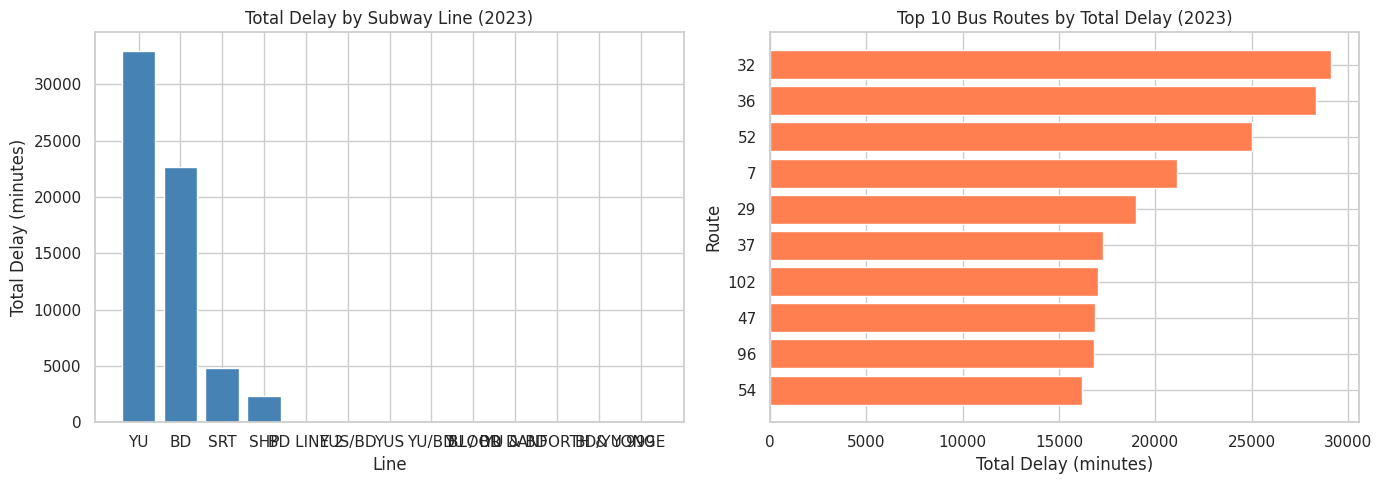

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# subway lines
axes[0].bar(q1_subway["line"], q1_subway["total_delay_min"], color="steelblue")
axes[0].set_title("Total Delay by Subway Line (2023)")
axes[0].set_xlabel("Line")
axes[0].set_ylabel("Total Delay (minutes)")

# top 10 bus routes
axes[1].barh(q1_bus["route"].astype(str), q1_bus["total_delay_min"], color="coral")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Bus Routes by Total Delay (2023)")
axes[1].set_xlabel("Total Delay (minutes)")
axes[1].set_ylabel("Route")

plt.tight_layout()
plt.show()

In [30]:
# Research Question 2: at what times of day do delays happen most?
# going to look at all 3 modes separately and compare

q2_subway = pd.read_sql_query("""
    SELECT hour, COUNT(*) AS incidents, SUM(delay_min) AS total_delay
    FROM subway
    GROUP BY hour
    ORDER BY hour
""", conn)

q2_streetcar = pd.read_sql_query("""
    SELECT hour, COUNT(*) AS incidents, SUM(delay_min) AS total_delay
    FROM streetcar
    GROUP BY hour
    ORDER BY hour
""", conn)

q2_bus = pd.read_sql_query("""
    SELECT hour, COUNT(*) AS incidents, SUM(delay_min) AS total_delay
    FROM bus
    GROUP BY hour
    ORDER BY hour
""", conn)

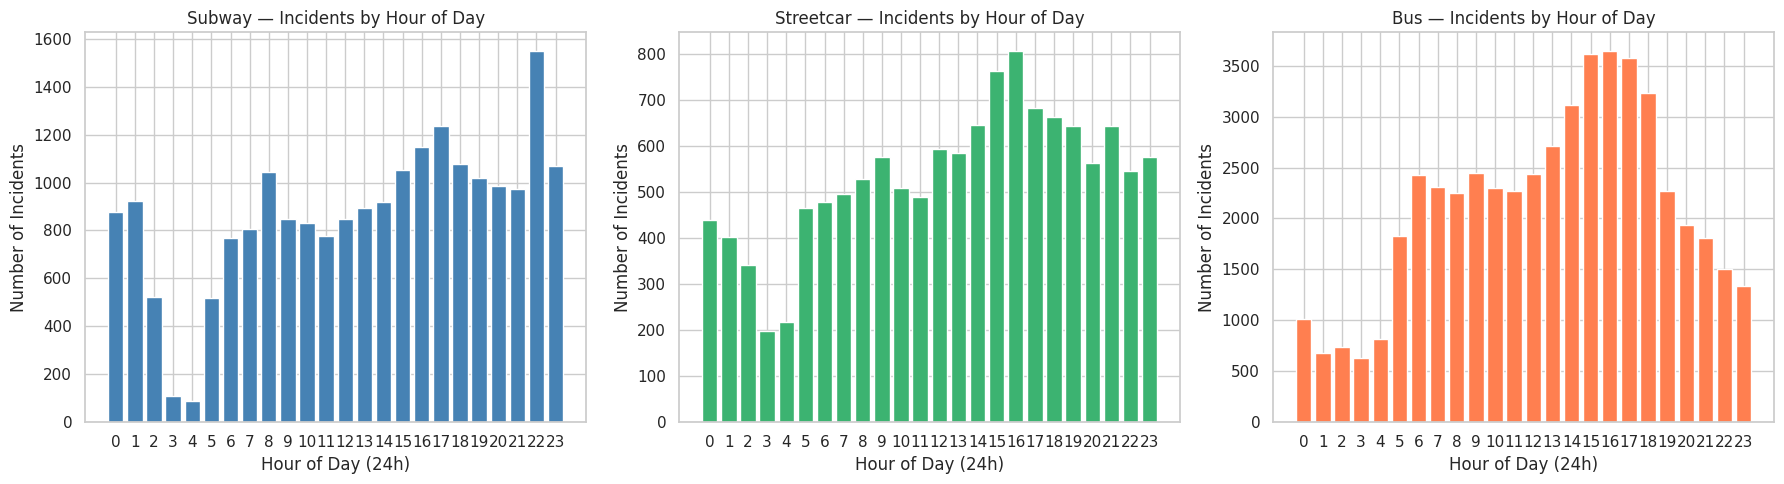

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df, title, color in zip(
    axes,
    [q2_subway, q2_streetcar, q2_bus],
    ["Subway", "Streetcar", "Bus"],
    ["steelblue", "mediumseagreen", "coral"]
):
    ax.bar(df["hour"], df["incidents"], color=color)
    ax.set_title(f"{title} — Incidents by Hour of Day")
    ax.set_xlabel("Hour of Day (24h)")
    ax.set_ylabel("Number of Incidents")
    ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# from looking at these, delays seem to cluster around rush hours (7-9am, 4-6pm)
# which makes sense since thats when there are more vehicles running

In [32]:
# Research Question 3: what are the most common causes/codes?
# each mode uses slightly different coding but the idea is the same

q3_subway = pd.read_sql_query("""
    SELECT code, COUNT(*) AS frequency, SUM(delay_min) AS total_delay_min
    FROM subway
    GROUP BY code
    ORDER BY frequency DESC
    LIMIT 10
""", conn)

q3_bus = pd.read_sql_query("""
    SELECT code, COUNT(*) AS frequency, SUM(delay_min) AS total_delay_min
    FROM bus
    GROUP BY code
    ORDER BY frequency DESC
    LIMIT 10
""", conn)

print("Top subway delay codes:")
print(q3_subway)
print("\nTop bus delay codes:")
print(q3_bus)

Top subway delay codes:
    code  frequency  total_delay_min
0   SUDP       3107             8239
1   MUIS       2473              193
2    SUO       2143             4722
3  MUPAA       1323             2854
4  MUIRS       1202               94
5  PUOPO        892             3074
6    MUO        824             1252
7   SUAP        634             1723
8  PUMEL        610                3
9   SUUT        595             5449

Top bus delay codes:
                    code  frequency  total_delay_min
0             Mechanical      17527           230994
1  Operations - Operator      10039           140654
2               Security       4426            50522
3        Collision - TTC       3603            43000
4              Diversion       3423           374535
5          General Delay       2961            73114
6     Emergency Services       2733            31247
7     Utilized Off Route       2126            28070
8  Cleaning - Unsanitary       1937            28310
9          Invest

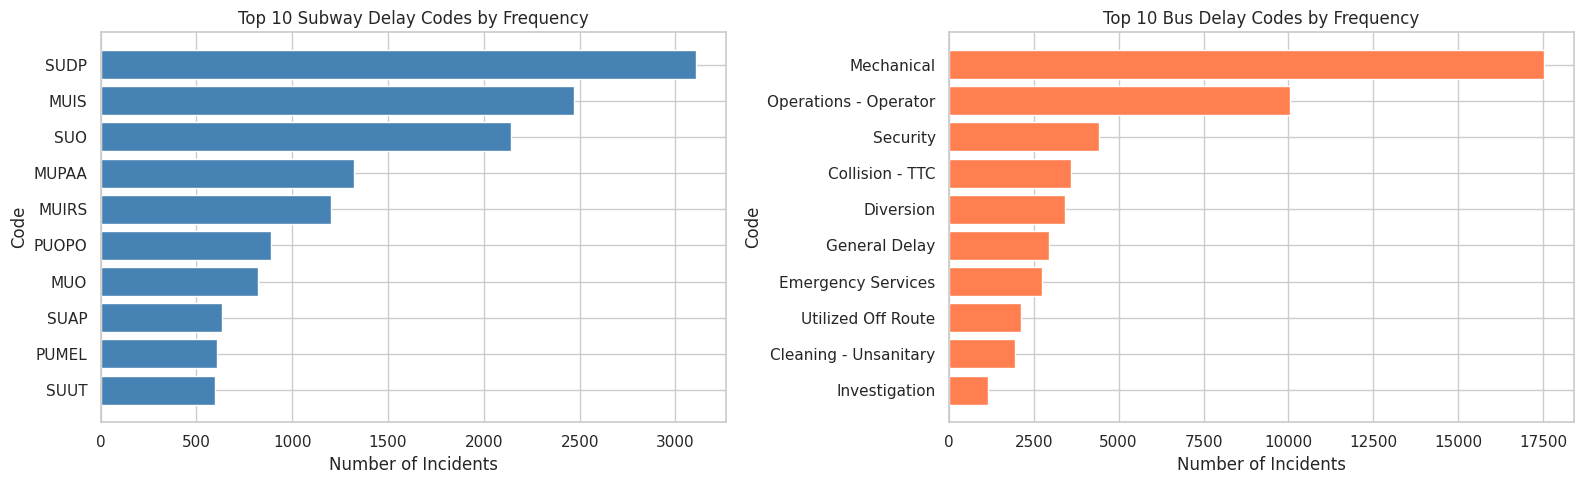

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(q3_subway["code"], q3_subway["frequency"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Subway Delay Codes by Frequency")
axes[0].set_xlabel("Number of Incidents")
axes[0].set_ylabel("Code")

axes[1].barh(q3_bus["code"], q3_bus["frequency"], color="coral")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Bus Delay Codes by Frequency")
axes[1].set_xlabel("Number of Incidents")
axes[1].set_ylabel("Code")

plt.tight_layout()
plt.show()

In [34]:
# Research Question 4: are delays worse on weekdays vs weekends?

q4 = pd.read_sql_query("""
    SELECT 'Subway' AS mode, is_weekend, COUNT(*) AS incidents, 
           ROUND(AVG(delay_min), 2) AS avg_delay, SUM(delay_min) AS total_delay
    FROM subway
    GROUP BY is_weekend

    UNION ALL

    SELECT 'Streetcar' AS mode, is_weekend, COUNT(*) AS incidents,
           ROUND(AVG(delay_min), 2) AS avg_delay, SUM(delay_min) AS total_delay
    FROM streetcar
    GROUP BY is_weekend

    UNION ALL

    SELECT 'Bus' AS mode, is_weekend, COUNT(*) AS incidents,
           ROUND(AVG(delay_min), 2) AS avg_delay, SUM(delay_min) AS total_delay
    FROM bus
    GROUP BY is_weekend
""", conn)

q4["day_type"] = q4["is_weekend"].map({0: "Weekday", 1: "Weekend"})
print(q4)

        mode  is_weekend  incidents  avg_delay  total_delay day_type
0     Subway           0      15742       2.99        47108  Weekday
1     Subway           1       5140       3.05        15694  Weekend
2  Streetcar           0       9298      15.75       146445  Weekday
3  Streetcar           1       3544      15.61        55328  Weekend
4        Bus           0      38414      20.43       784927  Weekday
5        Bus           1      12499      20.56       257039  Weekend


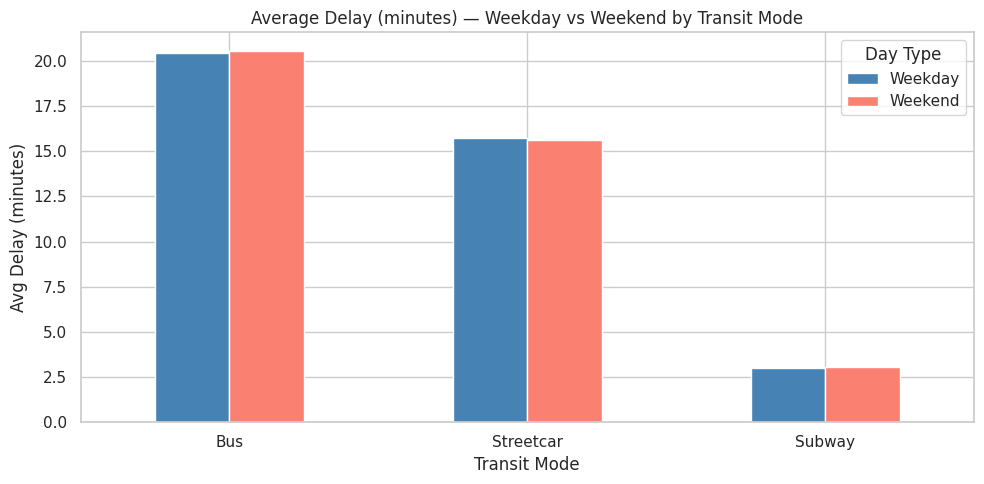

In [35]:
# pivot so i can plot grouped bars for each mode
q4_pivot = q4.pivot_table(index="mode", columns="day_type", values="avg_delay")

q4_pivot.plot(kind="bar", figsize=(10, 5), color=["steelblue", "salmon"])
plt.title("Average Delay (minutes) — Weekday vs Weekend by Transit Mode")
plt.ylabel("Avg Delay (minutes)")
plt.xlabel("Transit Mode")
plt.xticks(rotation=0)
plt.legend(title="Day Type")
plt.tight_layout()
plt.show()

In [36]:
# Research Question 5: how do delay patterns differ between subway, streetcar, and bus?
# combining all 3 into one dataframe with a "mode" label for easy comparison

subway_summary = subway[["delay_min", "hour", "is_weekend", "day_of_week"]].copy()
subway_summary["mode"] = "Subway"

streetcar_summary = streetcar[["delay_min", "hour", "is_weekend", "day_of_week"]].copy()
streetcar_summary["mode"] = "Streetcar"

bus_summary = bus[["delay_min", "hour", "is_weekend", "day_of_week"]].copy()
bus_summary["mode"] = "Bus"

all_modes = pd.concat([subway_summary, streetcar_summary, bus_summary], ignore_index=True)
all_modes.head()

,delay_min,hour,is_weekend,day_of_week,mode
0,3,2,1,Sunday,Subway
1,0,2,1,Sunday,Subway
2,0,2,1,Sunday,Subway
3,0,3,1,Sunday,Subway
4,0,7,1,Sunday,Subway


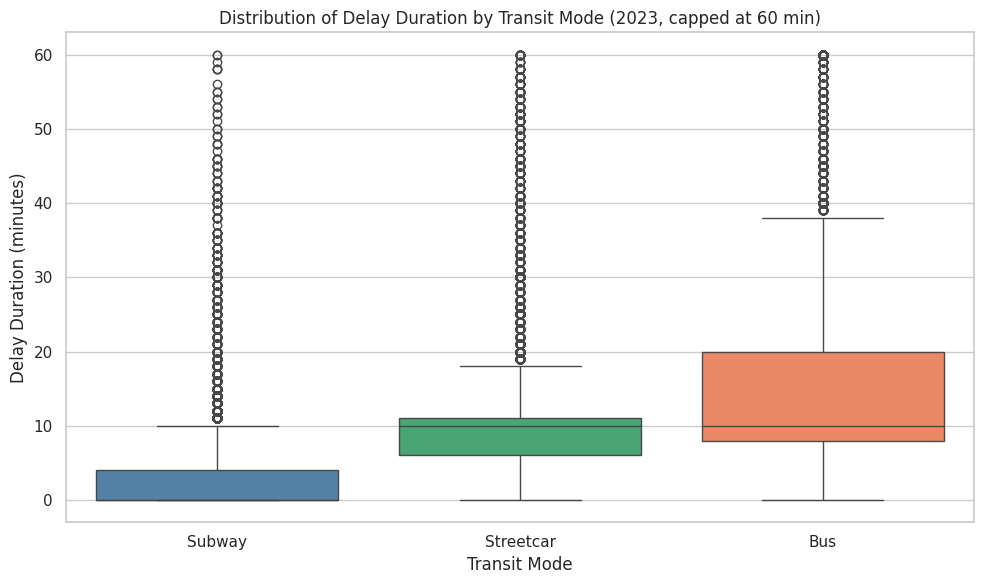

In [40]:
# box plot to compare the distribution of delay times across modes
# filtering out extreme outliers (>60 min) so the plot is actually readable

filtered = all_modes[all_modes["delay_min"] <= 60]

plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered, x="mode", y="delay_min", hue="mode",
            palette=["steelblue", "mediumseagreen", "coral"], legend=False)
plt.title("Distribution of Delay Duration by Transit Mode (2023, capped at 60 min)")
plt.xlabel("Transit Mode")
plt.ylabel("Delay Duration (minutes)")
plt.tight_layout()
plt.show()

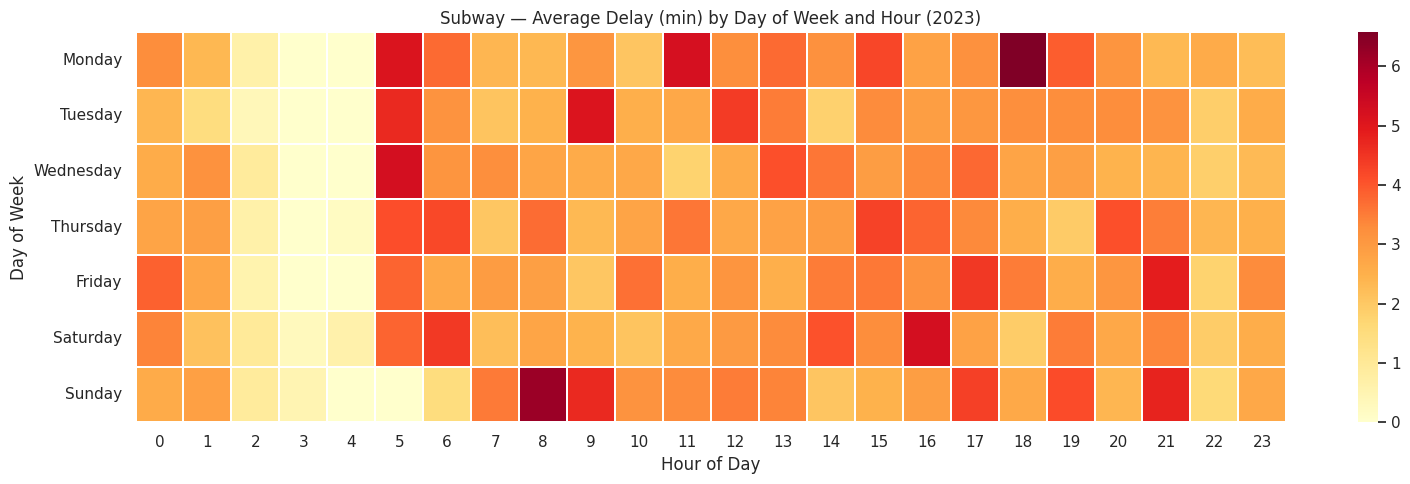

In [38]:
# heatmap of average delay by hour and day of week — doing this for subway only
# wanted to see if there's a clear pattern visually

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

subway_heat = subway.groupby(["day_of_week", "hour"])["delay_min"].mean().reset_index()
subway_heat_pivot = subway_heat.pivot(index="day_of_week", columns="hour", values="delay_min")
subway_heat_pivot = subway_heat_pivot.reindex(day_order)  # make sure days are in order

plt.figure(figsize=(16, 5))
sns.heatmap(subway_heat_pivot, cmap="YlOrRd", linewidths=0.3, annot=False)
plt.title("Subway — Average Delay (min) by Day of Week and Hour (2023)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

In [39]:
# quick summary stats to wrap everything up

print("=== 2023 TTC Delay Summary ===\n")

for name, df in [("Subway", subway), ("Streetcar", streetcar), ("Bus", bus)]:
    total = df["delay_min"].sum()
    avg = round(df["delay_min"].mean(), 2)
    incidents = len(df)
    print(f"{name}:")
    print(f"  Total incidents:    {incidents:,}")
    print(f"  Total delay (min):  {total:,}")
    print(f"  Avg delay per incident: {avg} min\n")

=== 2023 TTC Delay Summary ===

Subway:
  Total incidents:    20,882
  Total delay (min):  62,802
  Avg delay per incident: 3.01 min

Streetcar:
  Total incidents:    12,842
  Total delay (min):  201,773
  Avg delay per incident: 15.71 min

Bus:
  Total incidents:    50,913
  Total delay (min):  1,041,966
  Avg delay per incident: 20.47 min

